<a href="https://colab.research.google.com/github/Andresbeltran1030/CODIGOS/blob/main/ACA_No_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')


In [5]:
root = Path('/content/drive/MyDrive/Fundamentos de inteligencia de negocios')

df = pd.read_json(root / 'cancer-data.json')

# Eliminar columnas innecesarias
df.drop(columns=['id', ''], inplace=True, errors='ignore')

# Limpiar etiquetas
df['diagnosis'] = df['diagnosis'].astype(str).str.strip()
df = df[df['diagnosis'].isin(['M', 'B'])].copy()

# Convertir features a numérico
X = df.drop(columns='diagnosis').replace('desconocido', np.nan).apply(pd.to_numeric, errors='coerce')

# Eliminar filas con NaN
mask_valid = X.notna().all(axis=1)
X  = X[mask_valid].reset_index(drop=True)
df = df[mask_valid].reset_index(drop=True)

# Codificar target: M=1, B=0
le = LabelEncoder()
y  = le.fit_transform(df['diagnosis'])
feature_names = X.columns.tolist()

print(f"Registros válidos: {len(df)}")
print(f"Variables:         {X.shape[1]}")
print(f"\nBalance de clases:")
print(df['diagnosis'].value_counts())
df.head()

Registros válidos: 558
Variables:         30

Balance de clases:
diagnosis
B    349
M    209
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


FASE 1 –: CORRELACIÓN DE PEARSON
Pares con |r| > 0.90 (multicolinealidad):
  texture_mean  ↔  texture_worst  →  r = 0.913
  perimeter_mean  ↔  radius_worst  →  r = 0.926
  perimeter_mean  ↔  perimeter_worst  →  r = 0.928
  concavity_mean  ↔  concave points_mean  →  r = 0.928
  concave points_mean  ↔  concave points_worst  →  r = 0.912
  radius_se  ↔  perimeter_se  →  r = 0.973
  radius_se  ↔  area_se  →  r = 0.952
  perimeter_se  ↔  area_se  →  r = 0.938
  radius_worst  ↔  perimeter_worst  →  r = 0.994
  radius_worst  ↔  area_worst  →  r = 0.984
  perimeter_worst  ↔  area_worst  →  r = 0.978
  compactness_worst  ↔  concavity_worst  →  r = 0.902


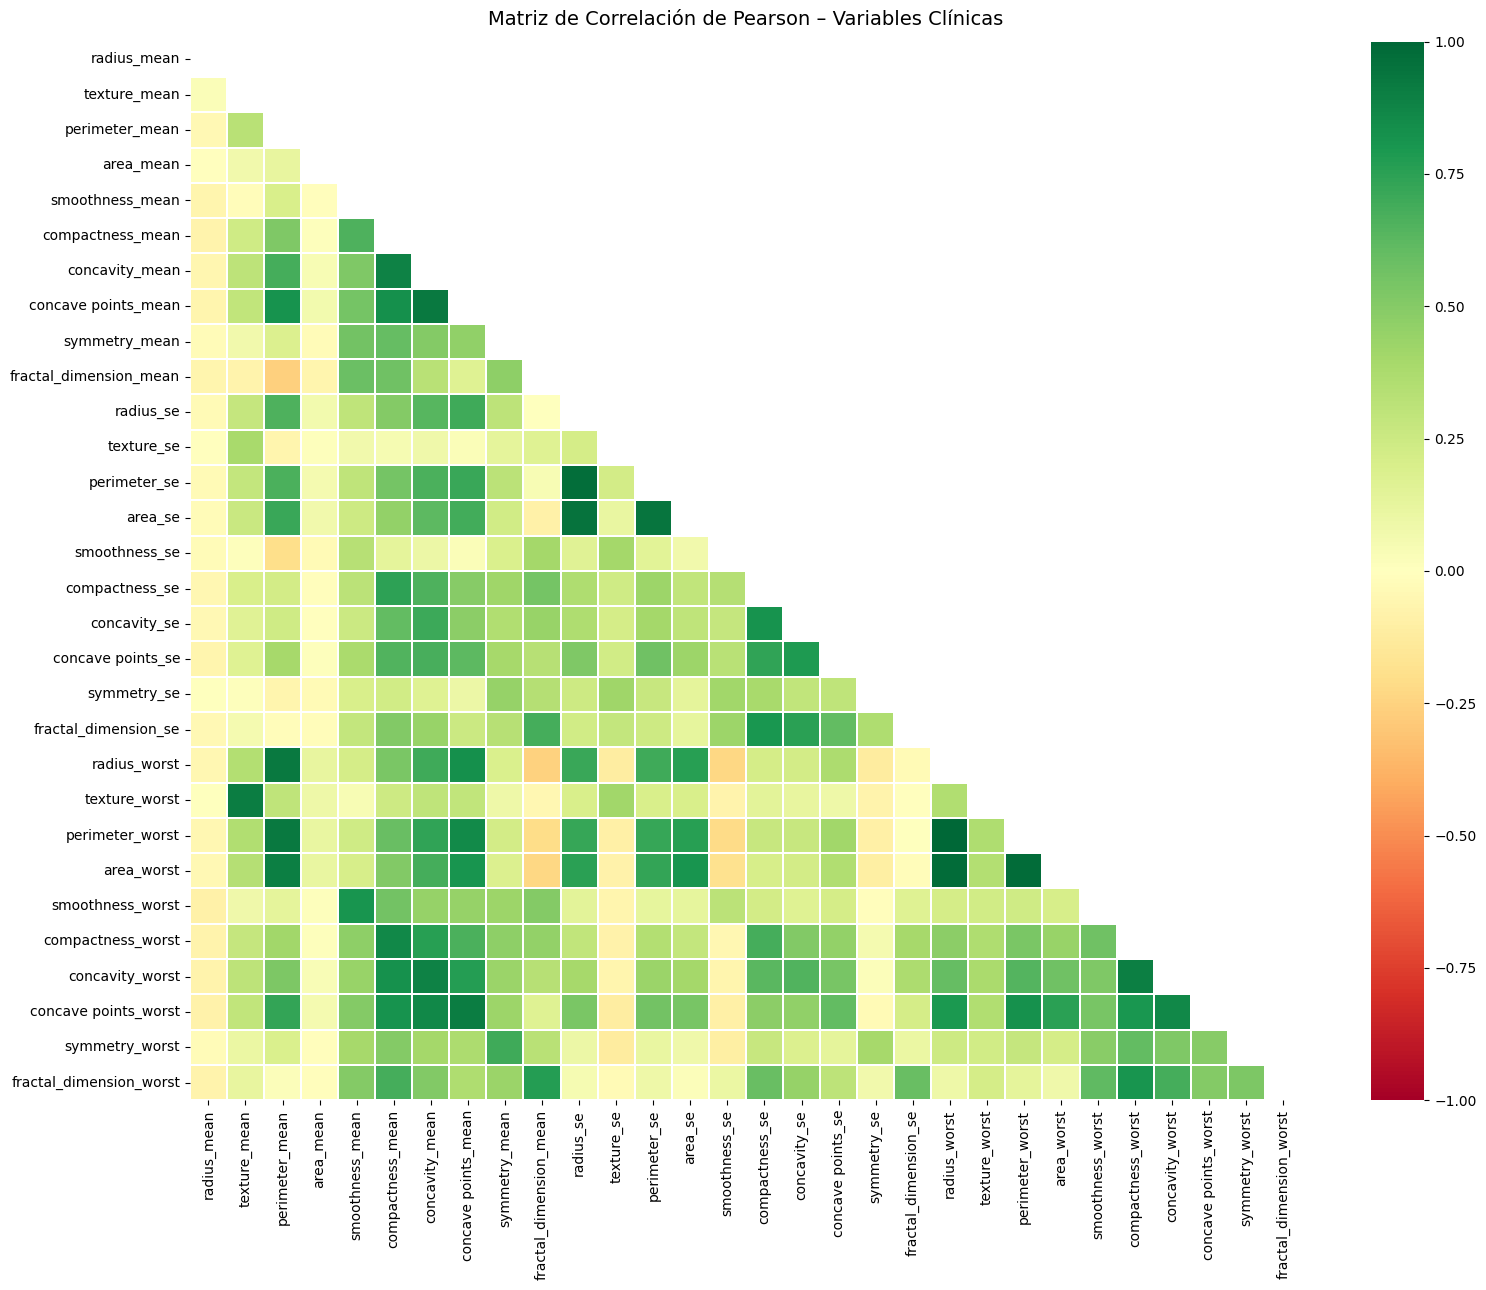

In [20]:

print("FASE 1 –: CORRELACIÓN DE PEARSON")


corr = X.corr()

# Pares con multicolinealidad alta
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.90:
            high_corr_pairs.append((corr.index[i], corr.columns[j], round(val, 3)))

print(f"Pares con |r| > 0.90 (multicolinealidad):")
for v1, v2, r in high_corr_pairs:
    print(f"  {v1}  ↔  {v2}  →  r = {r}")

# Heatmap
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            annot=False, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlación de Pearson – Variables Clínicas', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig(root / 'fig_corr.png', dpi=150, bbox_inches='tight')
plt.show()

FASE 1 – EDA: BALANCE DE CLASES
Benignos (B): 349  (62.5%)
Malignos (M): 209  (37.5%)
Relación B:M = 1.67:1
Accuracy trivial (siempre B) = 62.5% → métrica engañosa


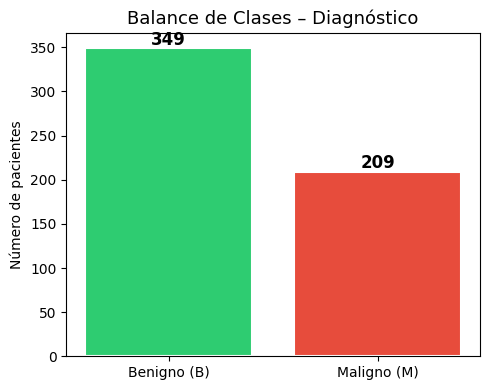

In [7]:
print("=" * 60)
print("FASE 1 – EDA: BALANCE DE CLASES")
print("=" * 60)

counts = df['diagnosis'].value_counts()
n_B, n_M = counts.get('B', 0), counts.get('M', 0)

print(f"Benignos (B): {n_B}  ({round(n_B/len(df)*100, 1)}%)")
print(f"Malignos (M): {n_M}  ({round(n_M/len(df)*100, 1)}%)")
print(f"Relación B:M = {round(n_B/n_M, 2)}:1")
print(f"Accuracy trivial (siempre B) = {round(n_B/len(df)*100,1)}% → métrica engañosa")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Benigno (B)', 'Maligno (M)'], [n_B, n_M],
       color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for i, v in enumerate([n_B, n_M]):
    ax.text(i, v + 4, str(v), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Balance de Clases – Diagnóstico', fontsize=13)
ax.set_ylabel('Número de pacientes')
plt.tight_layout()
plt.savefig(root / 'fig_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print("=" * 60)
print("FASE 1 – EDA: JUSTIFICACIÓN DEL ESCALAMIENTO")
print("=" * 60)

print(f"area_mean:       min={X['area_mean'].min():.1f}   max={X['area_mean'].max():.1f}")
print(f"smoothness_mean: min={X['smoothness_mean'].min():.4f}  max={X['smoothness_mean'].max():.4f}")



FASE 1 – EDA: JUSTIFICACIÓN DEL ESCALAMIENTO
area_mean:       min=-1.0   max=99999.0
smoothness_mean: min=0.0526  max=0.1634


In [9]:
print("=" * 60)
print("FASE 2 – SPLIT 80/20 Y ESCALAMIENTO")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Entrenamiento: {len(X_train)} registros (80%)")
print(f"Prueba:        {len(X_test)} registros (20%)")

# Fit solo en train → evita data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("\nEscalamiento aplicado correctamente.")

FASE 2 – SPLIT 80/20 Y ESCALAMIENTO
Entrenamiento: 446 registros (80%)
Prueba:        112 registros (20%)

Escalamiento aplicado correctamente.


In [11]:
print("=" * 60)
print("FASE 2 – ENTRENAMIENTO DE MODELOS")
print("=" * 60)

# Modelo A: Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]
print("✓ Modelo A: Regresión Logística entrenado")

# Modelo B: Árbol de Decisión
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)
y_prob_dt = dt.predict_proba(X_test_sc)[:, 1]
print("✓ Modelo B: Árbol de Decisión entrenado")

# Modelo C: K-Means
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(X_train_sc)
km_labels_test = km.predict(X_test_sc)

# Alinear cluster 0/1 con M=1 / B=0
cluster_means = [y_train[km.labels_ == c].mean() for c in [0, 1]]
km_labels_aligned = km_labels_test if cluster_means[0] > cluster_means[1] else 1 - km_labels_test
print("✓ Modelo C: K-Means entrenado")

print("""
DEBATE – ¿Es K-Means útil para clasificación?
  K-Means es NO supervisado: no usa etiquetas durante el entrenamiento.
  Se usa aquí de forma EXPLORATORIA: si K=2 reproduce las clases M/B,
  confirma que los datos tienen estructura natural separable.
  Como clasificador clínico NO es adecuado.
""")

FASE 2 – ENTRENAMIENTO DE MODELOS
✓ Modelo A: Regresión Logística entrenado
✓ Modelo B: Árbol de Decisión entrenado
✓ Modelo C: K-Means entrenado

DEBATE – ¿Es K-Means útil para clasificación?
  K-Means es NO supervisado: no usa etiquetas durante el entrenamiento.
  Se usa aquí de forma EXPLORATORIA: si K=2 reproduce las clases M/B,
  confirma que los datos tienen estructura natural separable.
  Como clasificador clínico NO es adecuado.



In [12]:
print("=" * 60)
print("FASE 3 – MÉTRICAS DE DESEMPEÑO")
print("=" * 60)

def calcular_metricas(y_true, y_pred, y_prob=None, nombre='Modelo'):
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    print(f"\n{'─'*45}")
    print(f"  {nombre}")
    print(f"{'─'*45}")
    print(f"  Accuracy:      {acc*100:.1f}%")
    print(f"  Recall  (M):   {rec*100:.1f}%")
    print(f"  Precision (M): {pre*100:.1f}%")
    print(f"  F1-Score:      {f1*100:.1f}%")
    print(f"  AUC:           {auc:.4f}" if auc else "  AUC:           N/A")
    print(f"\n  Reporte completo:")
    print(classification_report(y_true, y_pred, target_names=['Benigno', 'Maligno']))
    return dict(accuracy=acc, recall=rec, precision=pre, f1=f1, auc=auc)

m_lr = calcular_metricas(y_test, y_pred_lr, y_prob_lr, 'Regresión Logística')
m_dt = calcular_metricas(y_test, y_pred_dt, y_prob_dt, 'Árbol de Decisión')
m_km = calcular_metricas(y_test, km_labels_aligned, nombre='K-Means (ajustado)')

FASE 3 – MÉTRICAS DE DESEMPEÑO

─────────────────────────────────────────────
  Regresión Logística
─────────────────────────────────────────────
  Accuracy:      98.2%
  Recall  (M):   95.2%
  Precision (M): 100.0%
  F1-Score:      97.6%
  AUC:           0.9898

  Reporte completo:
              precision    recall  f1-score   support

     Benigno       0.97      1.00      0.99        70
     Maligno       1.00      0.95      0.98        42

    accuracy                           0.98       112
   macro avg       0.99      0.98      0.98       112
weighted avg       0.98      0.98      0.98       112


─────────────────────────────────────────────
  Árbol de Decisión
─────────────────────────────────────────────
  Accuracy:      91.1%
  Recall  (M):   85.7%
  Precision (M): 90.0%
  F1-Score:      87.8%
  AUC:           0.9221

  Reporte completo:
              precision    recall  f1-score   support

     Benigno       0.92      0.94      0.93        70
     Maligno       0.90      0

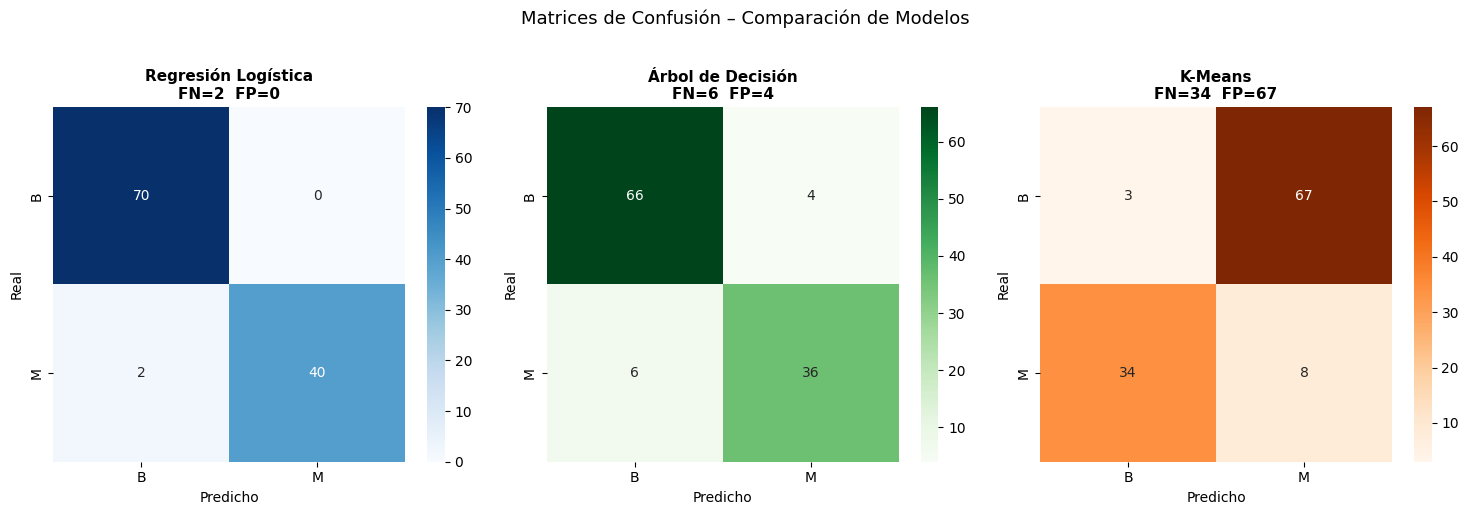


Falsos Negativos (tumores malignos NO detectados – error crítico):
  Regresión Logística: 2 FN
  Árbol de Decisión: 6 FN


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, y_pred, title, cmap in zip(
        axes,
        [y_pred_lr, y_pred_dt, km_labels_aligned],
        ['Regresión Logística', 'Árbol de Decisión', 'K-Means'],
        ['Blues', 'Greens', 'Oranges']):
    cm_vals = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm_vals, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['B', 'M'], yticklabels=['B', 'M'])
    tn, fp, fn, tp = cm_vals.ravel()
    ax.set_title(f'{title}\nFN={fn}  FP={fp}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión – Comparación de Modelos', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(root / 'fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFalsos Negativos (tumores malignos NO detectados – error crítico):")
for nombre, y_pred in [('Regresión Logística', y_pred_lr), ('Árbol de Decisión', y_pred_dt)]:
    fn = confusion_matrix(y_test, y_pred)[1][0]
    print(f"  {nombre}: {fn} FN")

FASE 3 – CURVAS ROC Y AUC


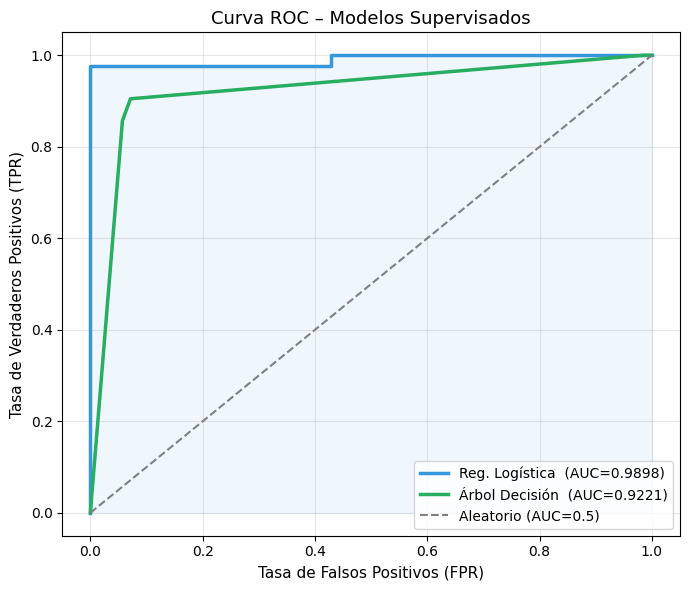

In [14]:
print("=" * 60)
print("FASE 3 – CURVAS ROC Y AUC")
print("=" * 60)

fig, ax = plt.subplots(figsize=(7, 6))
for y_prob, label, color in [
    (y_prob_lr, f'Reg. Logística  (AUC={m_lr["auc"]:.4f})', '#3498db'),
    (y_prob_dt, f'Árbol Decisión  (AUC={m_dt["auc"]:.4f})', '#27ae60'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2.5, label=label)

ax.fill_between(*roc_curve(y_test, y_prob_lr)[:2], alpha=0.08, color='#3498db')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC – Modelos Supervisados', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(root / 'fig_roc.png', dpi=150, bbox_inches='tight')
plt.show()

DESAFÍO FINAL – IMPORTANCIA DE VARIABLES
Variable del primer corte (nodo raíz): 'perimeter_worst'
Importancia Gini: 0.7628  (76.3%)

Top 10 variables:
perimeter_worst         0.762803
concave points_worst    0.131004
texture_mean            0.025590
texture_worst           0.023967
concavity_mean          0.023186
area_worst              0.010449
perimeter_se            0.009685
concave points_se       0.008530
area_mean               0.004785
symmetry_mean           0.000000


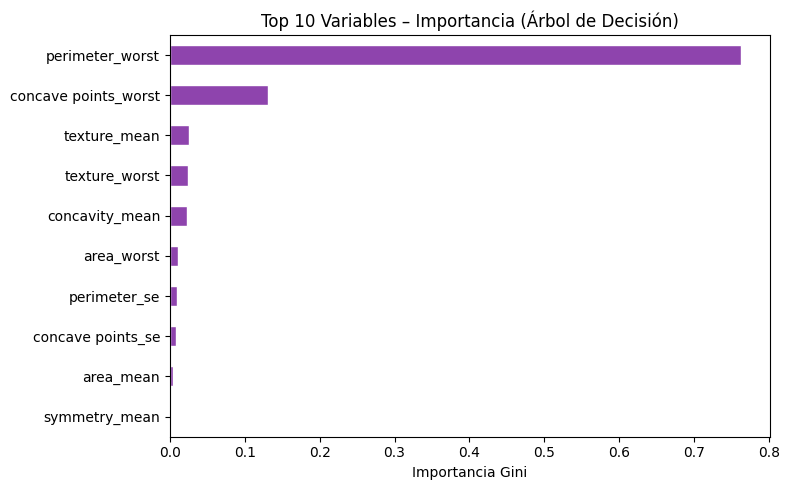

In [15]:
print("=" * 60)
print("DESAFÍO FINAL – IMPORTANCIA DE VARIABLES")
print("=" * 60)

importances = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)

print(f"Variable del primer corte (nodo raíz): '{importances.index[0]}'")
print(f"Importancia Gini: {importances.iloc[0]:.4f}  ({importances.iloc[0]*100:.1f}%)")
print("\nTop 10 variables:")
print(importances.head(10).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
importances.head(10).plot(kind='barh', ax=ax, color='#8e44ad', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Top 10 Variables – Importancia (Árbol de Decisión)', fontsize=12)
ax.set_xlabel('Importancia Gini')
plt.tight_layout()
plt.savefig(root / 'fig_importance.png', dpi=150, bbox_inches='tight')
plt.show()

DESAFÍO FINAL – K-MEANS vs ETIQUETAS REALES
Cluster K-Means     0    1
Diagnóstico Real          
B                  15  334
M                 168   41

→ Si hay coincidencia mayoritaria confirma separabilidad natural de los datos.


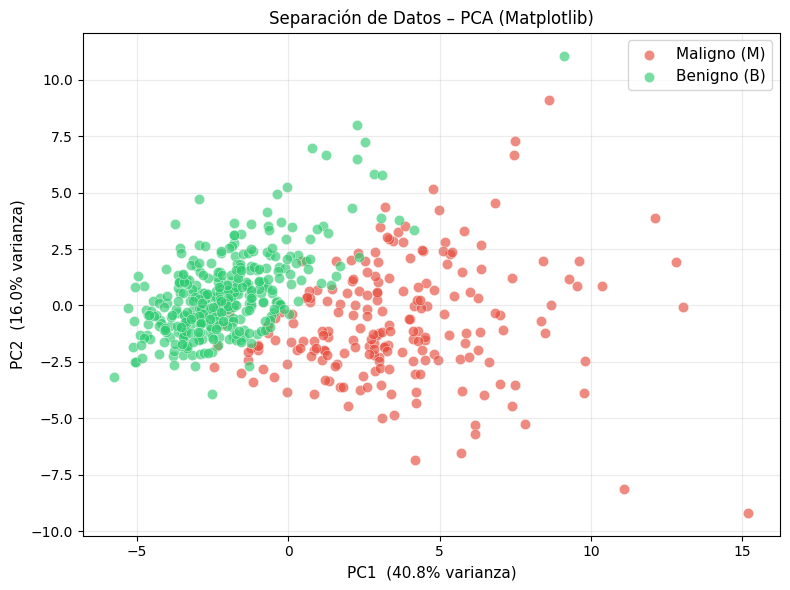

In [16]:
print("=" * 60)
print("DESAFÍO FINAL – K-MEANS vs ETIQUETAS REALES")
print("=" * 60)

km_all = KMeans(n_clusters=2, random_state=42, n_init=10)
km_all.fit(scaler.transform(X))
ct = pd.crosstab(df['diagnosis'].values, km_all.labels_,
                 rownames=['Diagnóstico Real'], colnames=['Cluster K-Means'])
print(ct)
print("\n→ Si hay coincidencia mayoritaria confirma separabilidad natural de los datos.")

# Gráfica PCA (obligatoria Matplotlib/Seaborn)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(scaler.transform(X))
var1, var2 = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, nombre in [('M', '#e74c3c', 'Maligno'), ('B', '#2ecc71', 'Benigno')]:
    idx = df[df['diagnosis'] == label].index.tolist()
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], c=color,
               label=f'{nombre} ({label})', alpha=0.65,
               edgecolors='white', linewidth=0.4, s=55)
ax.set_xlabel(f'PC1  ({var1:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2  ({var2:.1f}% varianza)', fontsize=11)
ax.set_title('Separación de Datos – PCA (Matplotlib)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(root / 'fig_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
print("=" * 60)
print("TABLA COMPARATIVA FINAL DE MÉTRICAS")
print("=" * 60)

tabla = pd.DataFrame({
    'Modelo':        ['Regresión Logística', 'Árbol de Decisión', 'K-Means'],
    'Accuracy':      [f"{m_lr['accuracy']*100:.1f}%", f"{m_dt['accuracy']*100:.1f}%", f"{m_km['accuracy']*100:.1f}%"],
    'Recall (M)':    [f"{m_lr['recall']*100:.1f}%",   f"{m_dt['recall']*100:.1f}%",   f"{m_km['recall']*100:.1f}%"],
    'Precision (M)': [f"{m_lr['precision']*100:.1f}%",f"{m_dt['precision']*100:.1f}%",f"{m_km['precision']*100:.1f}%"],
    'F1-Score':      [f"{m_lr['f1']*100:.1f}%",       f"{m_dt['f1']*100:.1f}%",       f"{m_km['f1']*100:.1f}%"],
    'AUC':           [f"{m_lr['auc']:.4f}",            f"{m_dt['auc']:.4f}",            'N/A'],
})

display(tabla)

fn_lr = confusion_matrix(y_test, y_pred_lr)[1][0]
fn_dt = confusion_matrix(y_test, y_pred_dt)[1][0]
print(f"\nFalsos Negativos → Reg. Logística: {fn_lr}  |  Árbol: {fn_dt}")
print(f"\n✅ Modelo recomendado: REGRESIÓN LOGÍSTICA")
print(f"   Mayor Recall, menor FN, AUC={m_lr['auc']:.4f}")
print(f"   Variable más discriminante: '{importances.index[0]}'")
print(f"\n📁 Figuras guardadas en tu Drive: {root}")

TABLA COMPARATIVA FINAL DE MÉTRICAS


,Modelo,Accuracy,Recall (M),Precision (M),F1-Score,AUC
0,Regresión Logística,98.2%,95.2%,100.0%,97.6%,0.9898
1,Árbol de Decisión,91.1%,85.7%,90.0%,87.8%,0.9221
2,K-Means,9.8%,19.0%,10.7%,13.7%,N/A



Falsos Negativos → Reg. Logística: 2  |  Árbol: 6

✅ Modelo recomendado: REGRESIÓN LOGÍSTICA
   Mayor Recall, menor FN, AUC=0.9898
   Variable más discriminante: 'perimeter_worst'

📁 Figuras guardadas en tu Drive: /content/drive/MyDrive/Fundamentos de inteligencia de negocios
